# Preliminary SVM Analysis of MIMIC III dataset
### This notebook will perfrom an SVM analysis of the cleaned and formated data

Februrary 17th, 2025

Maxime Bouthillier

In [1]:
import pandas as pd
import os 
from joblib import load
from sklearn import svm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Setting the Directory
directory = '/Users/maxb/Library/CloudStorage/OneDrive-UniversityofWaterloo/Hospital Research/Datasets/MIMIC-III_demo'
os.chdir(directory)

# Loading dataframe from Pipeline notebook
df = load("Master_Dataframe.joblib")

In [3]:
# Dropping the unnecessary columns
df = df.drop(['inputs', 'events', 'prescriptions', 'procedures', 'labs', 'subject_id', 'admittime', 'dischtime'], axis=1)

# Altering column values to integer (categorical) or float objects
for col, col_values in df.items():
    if df[col].dtype == ('O'):
        df[col] = df[col].astype('category').cat.codes

    elif df[col].dtype == ('<m8[ns]'):
        df[col] = df[col].dt.total_seconds()

### PCA to 2D

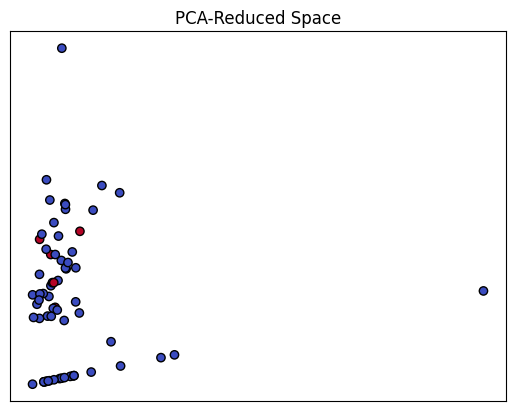

In [4]:
y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xticks([])
plt.yticks([])
plt.title("PCA-Reduced Space")
plt.style.use('bmh')
plt.show()

This is clearly not seperable utilizing any of the available kernels